In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pycountry

import pypsa
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
from pathlib import Path

import cartopy.crs as ccrs
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import box
from matplotlib.offsetbox import AnnotationBbox, AuxTransformBox
from matplotlib.patches import Wedge
from matplotlib.patches import Patch
import matplotlib.path as mpath
import matplotlib.transforms as mtransforms
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerPatch
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.font_manager import FontProperties
from IPython.display import display, HTML, Markdown
from matplotlib.font_manager import FontProperties
from functools import reduce
from collections import defaultdict
import plotly.express as px
import plotly.graph_objects as go
from shapely.geometry import LineString
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import yaml
from collections import OrderedDict
import warnings
warnings.filterwarnings("ignore")


In [2]:
path = r"C:\Users\Lella\Documents\UNI\PyPSA\pypsa-earth\results\networks\elec_s_10_ec_lcopt_Co2L-3h.nc"
n = pypsa.Network(path)

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [ ]:
#Grid info
n

PyPSA Network
Components:
 - Bus: 30
 - Carrier: 23
 - Generator: 71
 - GlobalConstraint: 1
 - Line: 10
 - Link: 40
 - Load: 10
 - StorageUnit: 2
 - Store: 20
Snapshots: 2920

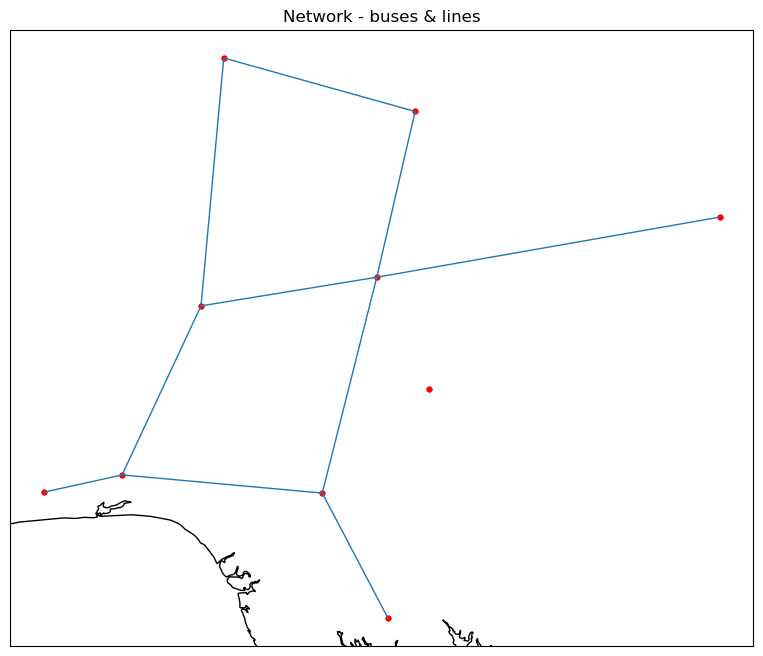

In [ ]:
# Nodal coordinates
bus_geo = gpd.GeoDataFrame(
    n.buses,
    geometry=gpd.points_from_xy(n.buses.x, n.buses.y),
    crs="EPSG:4326"
)

# Lines
line_geo = gpd.GeoDataFrame(
    n.lines,
    geometry=[
        LineString([(n.buses.loc[l.bus0].x, n.buses.loc[l.bus0].y),
                    (n.buses.loc[l.bus1].x, n.buses.loc[l.bus1].y)])
        for _, l in n.lines.iterrows()
    ],
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
ax.set_title("Network - buses & lines")

line_geo.plot(ax=ax, linewidth=1)
bus_geo.plot(ax=ax, color="red", markersize=10)

plt.show()


In [33]:
#Installed transmission
ac = n.lines.s_nom_opt.sum()
dc = n.links[n.links.carrier.str.contains("DC", case=False)].p_nom_opt.sum()
print("AC transmission (MVA):", ac)
print("HVDC transmission (MW):", dc)

AC transmission (MVA): 23668.422323906016
HVDC transmission (MW): 0.0


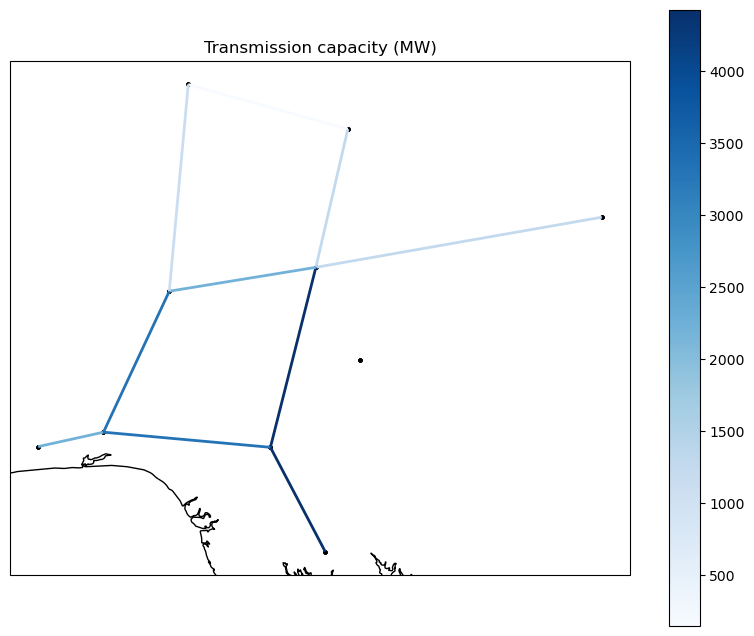

In [9]:
line_geo["capacity"] = n.lines.s_nom_opt
fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_title("Transmission capacity (MW)")
ax.coastlines()

line_geo.plot(
    ax=ax,
    column="capacity",
    cmap="Blues",
    linewidth=2,
    legend=True
)
bus_geo.plot(ax=ax,color="black",markersize=5)
plt.show()


In [ ]:
#Average flows on the lines
(n.lines_t.p0.abs().mean()).sort_values(ascending=False)

Line
3    1069.162360
5     642.473352
6     624.416190
2     538.553320
7     504.238886
1     375.482365
9     302.043468
4     255.582232
0     205.107938
8      30.389881
dtype: float64

In [5]:
#Line flows congestions (% of max load)
loading = (n.lines_t.p0.abs().max() / n.lines.s_nom) * 100
loading.sort_values(ascending=False)

Line
2    70.000000
1    70.000000
9    70.000000
8    56.994029
3    51.603897
6    39.701993
7    37.357182
4    34.729737
5    30.816308
0    14.691998
dtype: float64

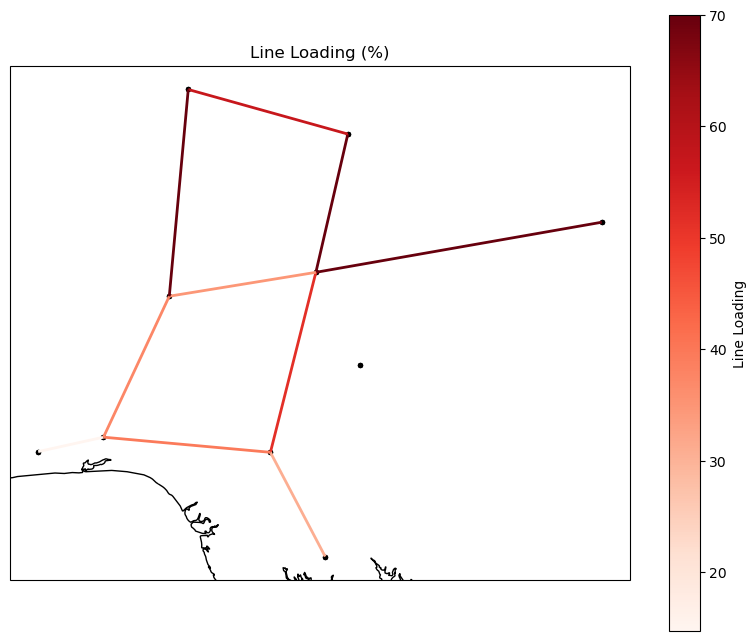

In [6]:
#Line flows congestions (% of max load)
line_geo["loading"] = loading.values

fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
ax.set_title("Line Loading (%)")

line_geo.plot(
    ax=ax,
    column="loading",
    cmap="Reds",
    linewidth=2,
    legend=True,
    legend_kwds={"label": "Line Loading"}
)

bus_geo.plot(ax=ax, color="black", markersize=8)
plt.show()

carrier
CCGT             1.382695e+04
solar            1.158735e+04
load shedding    8.740136e+03
lignite          6.000000e+02
coal             2.845000e+02
oil              2.000000e+01
onwind           1.132703e-08
offwind-ac       0.000000e+00
offwind-dc       0.000000e+00
Name: p_nom_opt, dtype: float64

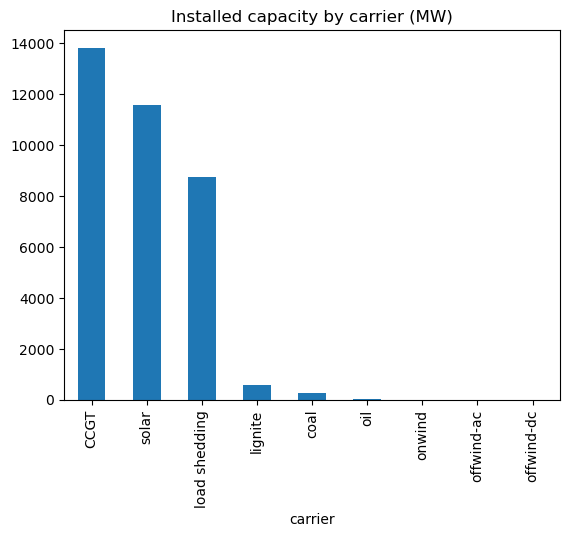

In [25]:
#Installed capacity by tecnology
cap = n.generators.groupby("carrier").p_nom_opt.sum().sort_values(ascending=False)
cap.plot(kind="bar", title="Installed capacity by carrier (MW)")
cap

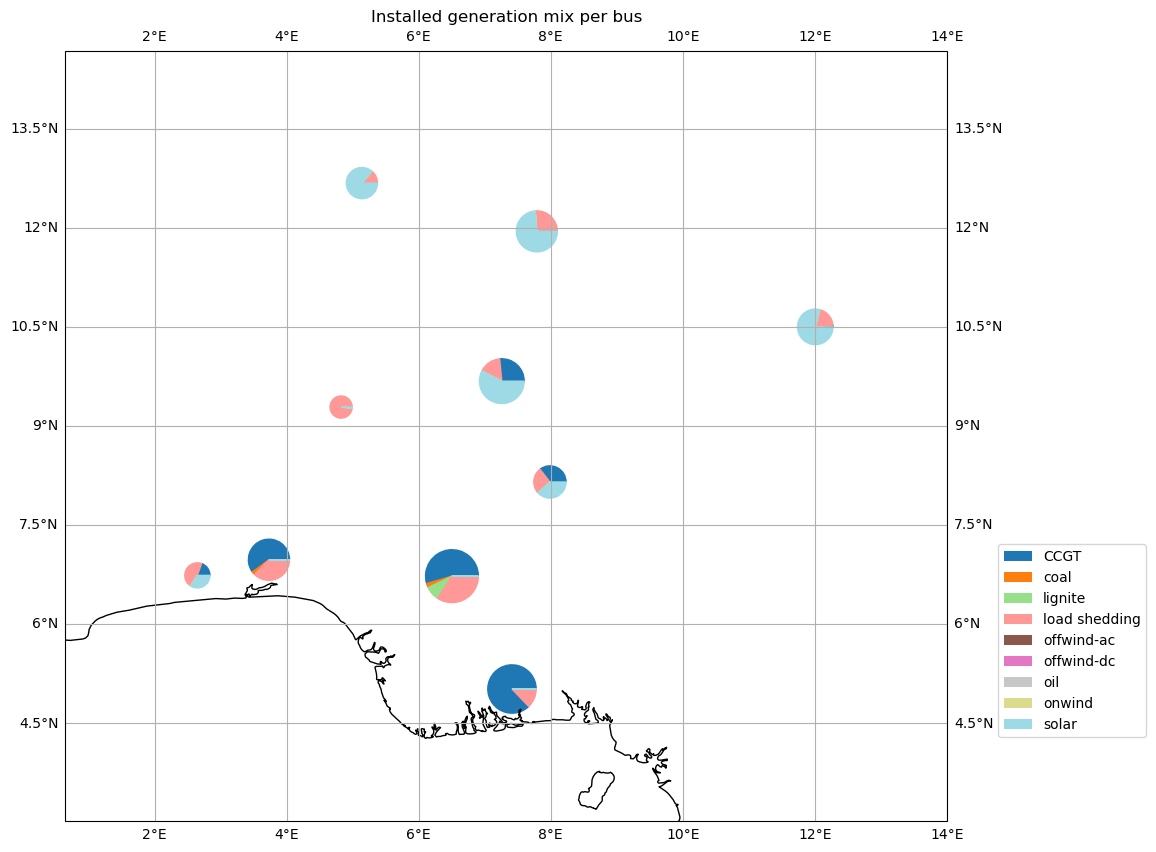

In [14]:
#Installed generation mix per bus

# Nodal generation capacity
gen = n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum().unstack().fillna(0)

# Bus coordinates
bus_pos = n.buses[["x","y"]]

# Colori per i carrier
carriers = gen.columns
colors = plt.cm.tab20(np.linspace(0,1,len(carriers)))
carrier_colors = dict(zip(carriers, colors))

fig, ax = plt.subplots(figsize=(12,10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_title("Installed generation mix per bus")
ax.coastlines()
ax.gridlines(draw_labels=True)

for bus in gen.index:
    x, y = bus_pos.loc[bus]
    values = gen.loc[bus]
    values = values[values > 0]  
    total = values.sum()
    if total == 0:
        continue

    # raggio proporzionale alla capacità
    scale = 0.4          # prova valori 0.2–0.5
    radius = scale * (0.4 + 0.6 * (total / gen.sum(axis=1).max()))

    start = 0
    for carrier, val in values.items():
        frac = val / total
        wedge = Wedge((x, y), radius, start*360, (start+frac)*360, 
                      color=carrier_colors[carrier])
        ax.add_patch(wedge)
        start += frac

# legenda carriers
legend_handles = [Patch(facecolor=carrier_colors[c], label=c) for c in carriers]
ax.legend(handles=legend_handles, loc="lower left", bbox_to_anchor=(1.05, 0.1))

ax.set_extent([
    bus_pos.x.min()-2, bus_pos.x.max()+2,
    bus_pos.y.min()-2, bus_pos.y.max()+2
])

plt.show()




In [24]:
#System energy balance (MWh)
n.statistics.energy_balance()

component    carrier             bus_carrier     
StorageUnit  Reservoir & Dam     Ac                  5.220270e+06
Load         -                   Ac                 -4.861887e+07
Link         H2 electrolysis     Ac                 -2.000000e-05
             H2 fuel cell        Hydrogen Storage   -1.000000e-05
             battery charger     Ac                 -2.300000e-04
             battery discharger  Battery Storage    -2.200000e-04
             H2 electrolysis     Hydrogen Storage    1.000000e-05
             H2 fuel cell        Ac                  1.000000e-05
             battery charger     Battery Storage     2.200000e-04
             battery discharger  Ac                  2.100000e-04
Generator    Coal                Ac                  2.103595e+06
             Combined-Cycle Gas  Ac                  1.992944e+07
             Lignite             Ac                  4.878076e+06
             Onshore Wind        Ac                  1.000000e-05
             Solar        

**Top exporters (MWh)**

,net_MWh
Bus,
NG0 1,1189798.12
NG0 7,1140354.69
NG0 5,1075416.18
NG0 6,342278.14
NG0 3,74381.64
NG0 0,1557.38
NG0 7 battery,0.00
NG0 0 battery,0.00
NG0 5 battery,0.00


**Top importers (MWh)**

,net_MWh
Bus,
NG0 2,-2696624.27
BJ0 0,-598915.18
NG0 4,-528246.70
NG1 0,-0.00
NG0 1 battery,-0.00
BJ0 0 battery,-0.00
NG0 4 battery,-0.00
NG1 0 battery,-0.00
NG0 7 H2,0.00


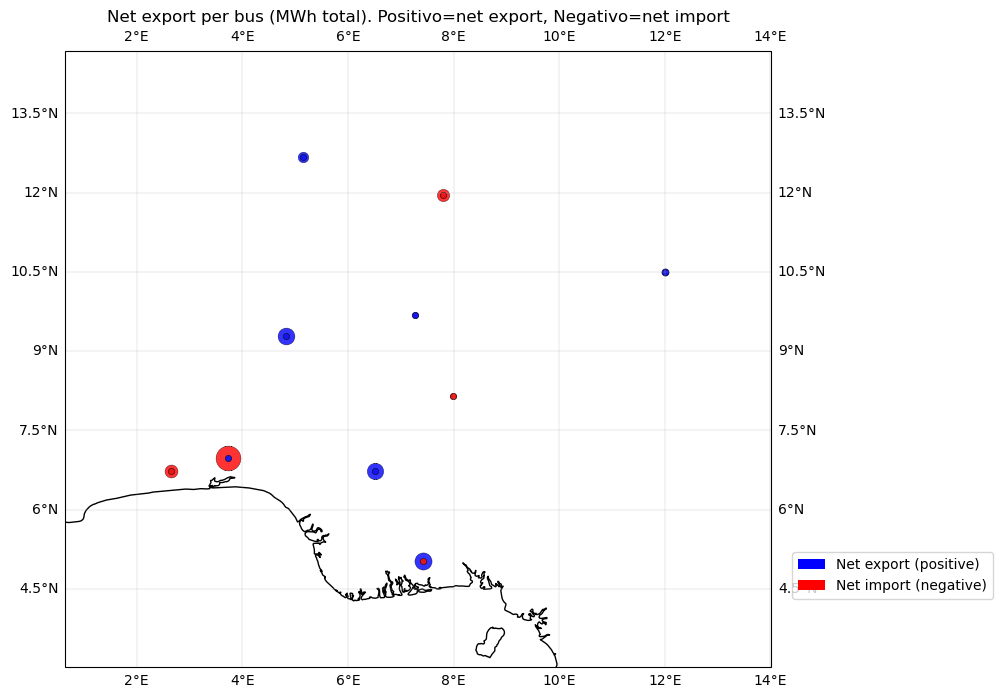

In [18]:
# --- Net import/export per bus over all snapshots ---
# n.buses_t.p is typically bus injections (positive = injection -> export)
try:
    net_export = n.buses_t.p.sum()  # sum over time -> Series indexed by bus
    net_export_MWh = net_export.reindex(n.buses.index).fillna(0)

except Exception as e:
    print("Errore nel calcolo net export:", e)
    net_export_MWh = None

if net_export_MWh is None:
    print("Net export non calcolabile")
else:
    bus_geo = gpd.GeoDataFrame(n.buses, geometry=gpd.points_from_xy(n.buses.x, n.buses.y), crs="EPSG:4326")
    bus_geo["net_MWh"] = net_export_MWh.values

    fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.set_title("Net export per bus (MWh total). Positivo=net export, Negativo=net import")
    ax.coastlines()
    ax.gridlines(draw_labels=True, linewidth=0.2)

    # color for sign, size for magnitude
    bus_geo["abs"] = bus_geo["net_MWh"].abs()
    sizes = 20 + (bus_geo["abs"] / max(1, bus_geo["abs"].max())) * 300
    colors = bus_geo["net_MWh"].apply(lambda v: "blue" if v>0 else ("red" if v<0 else "gray"))

    for _, row in bus_geo.iterrows():
        ax.scatter(row.geometry.x, row.geometry.y, s=sizes.loc[row.name], color=colors.loc[row.name], transform=ccrs.PlateCarree(), alpha=0.8, edgecolor="k", linewidth=0.3)

    # legend patches
    handles = [Patch(facecolor="blue", label="Net export (positive)"),
               Patch(facecolor="red", label="Net import (negative)")]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(1.02, 0.1))

    # table top exporters / importers
    display(Markdown("**Top exporters (MWh)**"))
    display(bus_geo.sort_values("net_MWh", ascending=False)[["net_MWh"]].head(10).round(2))
    display(Markdown("**Top importers (MWh)**"))
    display(bus_geo.sort_values("net_MWh", ascending=True)[["net_MWh"]].head(10).round(2))

    ax.set_extent([n.buses.x.min()-2, n.buses.x.max()+2, n.buses.y.min()-2, n.buses.y.max()+2])
    plt.show()


carrier
CCGT             6.643147e+06
solar            5.495830e+06
lignite          1.626025e+06
coal             7.011983e+05
onwind           1.737340e-06
oil              1.627892e-07
load shedding    1.873867e-09
offwind-ac       0.000000e+00
offwind-dc       0.000000e+00
dtype: float64

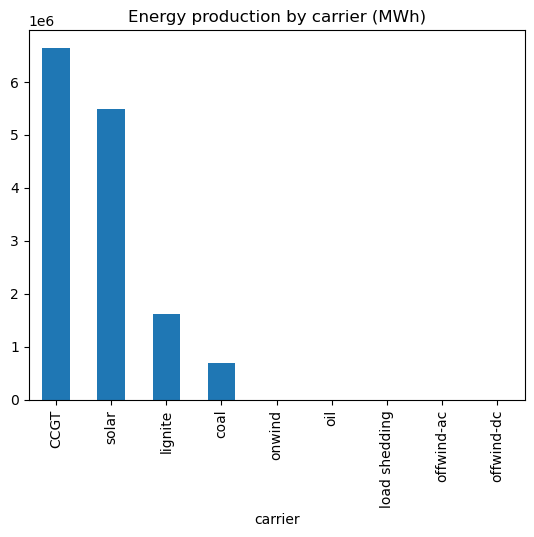

In [ ]:
#Energy production by carrier (MWh)
energy = n.generators_t.p.sum().groupby(n.generators.carrier).sum().sort_values(ascending=False)
energy.plot(kind="bar", title="Energy production by carrier (MWh)")
energy

<Axes: title={'center': 'State of Charge Storage Units'}, xlabel='snapshot'>

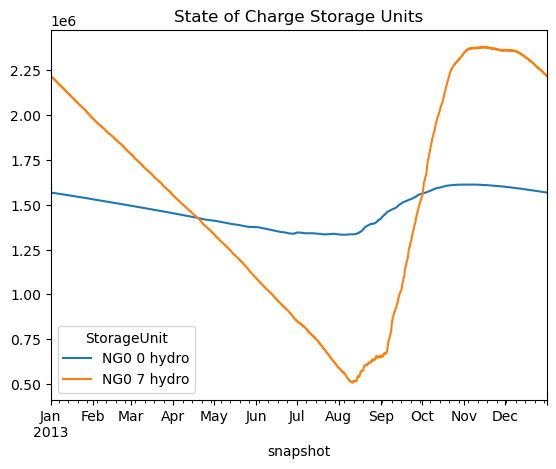

In [ ]:
#Storage state of charge
n.storage_units_t.state_of_charge.plot(title="State of Charge Storage Units")

**Buses with storage (power MW, energy MWh)**

,stor_p_MW,stor_e_MWh
Bus,,
NG0 7,1338.0,0.0
NG0 0,1300.0,0.0


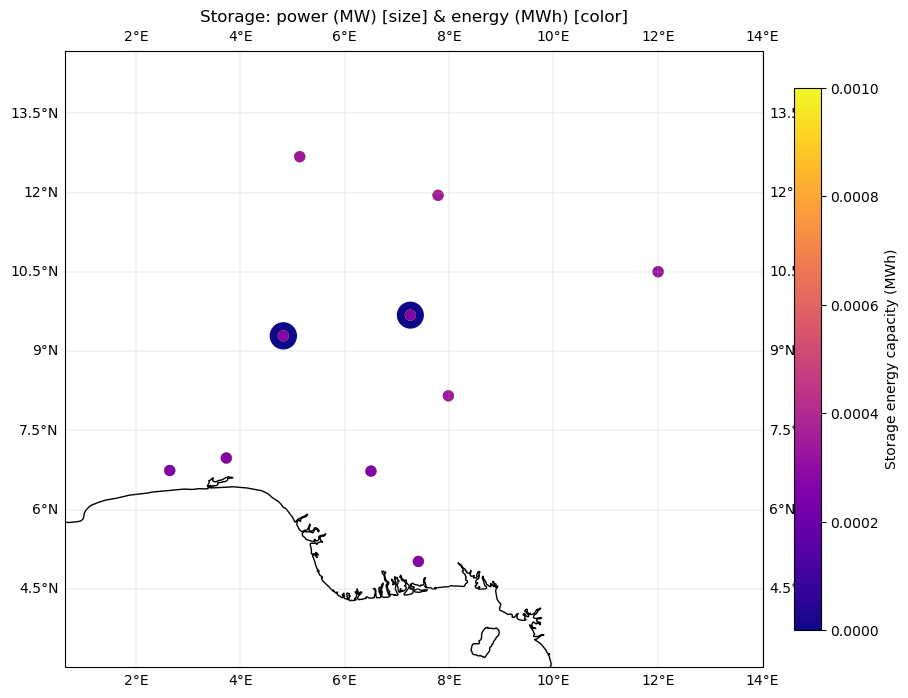

In [17]:
# --- Storage (power + energy) per bus ---
# storage_units may have p_nom_opt; stores may have e_nom_opt
try:
    storage_power = pd.Series(0.0, index=n.buses.index)
    storage_energy = pd.Series(0.0, index=n.buses.index)

    if hasattr(n, "storage_units") and len(n.storage_units) > 0:
        if "p_nom_opt" in n.storage_units.columns:
            sp = n.storage_units.p_nom_opt.groupby(n.storage_units.bus).sum()
            storage_power = storage_power.add(sp.reindex(storage_power.index).fillna(0))
        elif "p_nom" in n.storage_units.columns:
            sp = n.storage_units.p_nom.groupby(n.storage_units.bus).sum()
            storage_power = storage_power.add(sp.reindex(storage_power.index).fillna(0))

    if hasattr(n, "stores") and len(n.stores) > 0:
        if "e_nom_opt" in n.stores.columns:
            se = n.stores.e_nom_opt.groupby(n.stores.bus).sum()
            storage_energy = storage_energy.add(se.reindex(storage_energy.index).fillna(0))
        elif "e_nom" in n.stores.columns:
            se = n.stores.e_nom.groupby(n.stores.bus).sum()
            storage_energy = storage_energy.add(se.reindex(storage_energy.index).fillna(0))

except Exception as e:
    print("Errore nel calcolo storage:", e)
    storage_power = None
    storage_energy = None

if storage_power is None:
    print("Nessun dato storage disponibile")
else:
    bus_geo = gpd.GeoDataFrame(n.buses, geometry=gpd.points_from_xy(n.buses.x, n.buses.y), crs="EPSG:4326")
    bus_geo["stor_p_MW"] = storage_power.values
    bus_geo["stor_e_MWh"] = storage_energy.values

    fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.set_title("Storage: power (MW) [size] & energy (MWh) [color]")
    ax.coastlines()
    ax.gridlines(draw_labels=True, linewidth=0.2)

    sizes = 50 + (bus_geo["stor_p_MW"] / max(1, bus_geo["stor_p_MW"].max())) * 300
    cmap = "plasma"
    vmax = max(bus_geo["stor_e_MWh"].max(), 1e-3)
    sc = bus_geo.plot(ax=ax, column="stor_e_MWh", cmap=cmap, markersize=sizes, legend=False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.035, pad=0.04)
    cbar.set_label("Storage energy capacity (MWh)")

    # show table of buses with storage
    sttab = bus_geo[bus_geo["stor_p_MW"] > 0][["stor_p_MW","stor_e_MWh"]].sort_values("stor_p_MW", ascending=False)
    display(Markdown("**Buses with storage (power MW, energy MWh)**"))
    display(sttab.round(2))

    ax.set_extent([n.buses.x.min()-2, n.buses.x.max()+2, n.buses.y.min()-2, n.buses.y.max()+2])
    plt.show()


In [13]:
#Renewables curtailment (max potential energy - used energy)
gen = n.generators_t.p_max_pu.multiply(n.generators.p_nom_opt).sum(axis=0)
use = n.generators_t.p.sum(axis=0)
curt = gen - use
curt.sort_values(ascending=False)

Generator
NG0 4 solar      2.612907e+04
NG0 6 solar      1.802897e+04
NG1 0 solar      1.283502e+04
NG0 3 solar      1.082509e+04
NG0 2 solar      1.789520e-03
                     ...     
NG0 5 coal      -4.225109e+05
NG1 0 CCGT      -7.428915e+05
NG0 5 lignite   -1.626025e+06
NG0 1 CCGT      -2.583656e+06
NG0 5 CCGT      -3.316600e+06
Length: 71, dtype: float64

**Top 10 curtailment (MWh)**

,curtail_MWh
Bus,
NG0 4,26129.07
NG0 6,18028.97
NG1 0,12835.02
NG0 3,10825.09
NG0 2,0.00
NG0 0,0.00
NG0 5,0.00
NG0 1,0.00
NG0 7,0.00


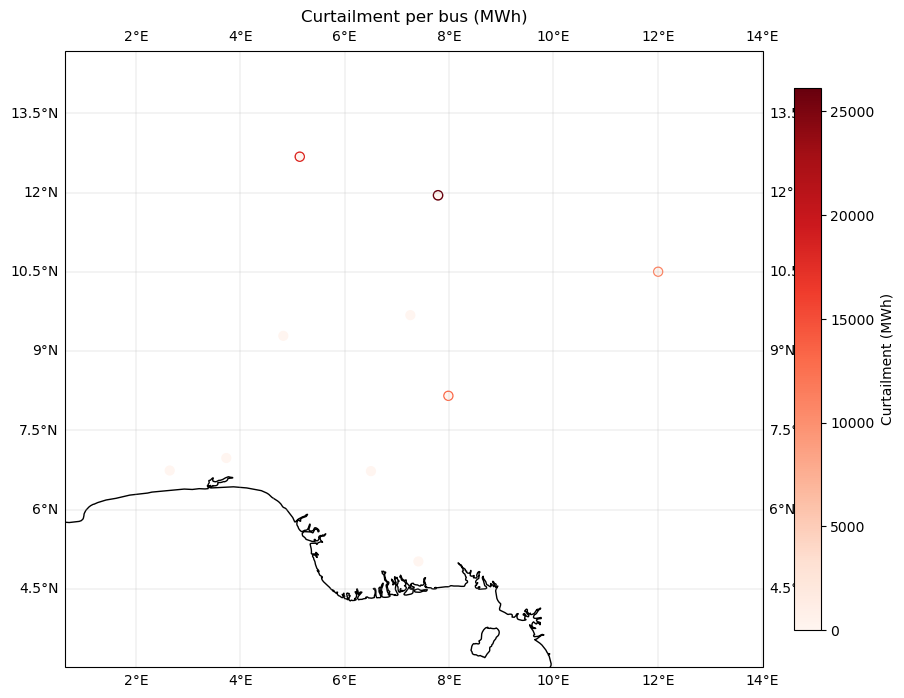

In [16]:
# --- Curtailment per bus ---
try:
    p_max = n.generators_t.p_max_pu.multiply(n.generators.p_nom_opt, axis=1)  # potential gen time series (MW)
    produced = n.generators_t.p  # actual generation (MW)
    curt_by_gen = (p_max - produced).clip(lower=0).sum()  # total curtailed MWh per generator (sum over time)
    # map to bus
    curt_by_bus = curt_by_gen.groupby(n.generators.bus).sum()
    curt_by_bus_MWh = curt_by_bus.reindex(n.buses.index).fillna(0)
except Exception as e:
    print("Errore nel calcolo curtailment:", e)
    curt_by_bus_MWh = None

if curt_by_bus_MWh is None:
    print("Curtailment non calcolabile (mancano dati)")
else:
    bus_geo = gpd.GeoDataFrame(n.buses, geometry=gpd.points_from_xy(n.buses.x, n.buses.y), crs="EPSG:4326")
    bus_geo["curtail_MWh"] = curt_by_bus_MWh.values / 1.0  # MWh

    fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.set_title("Curtailment per bus (MWh)")
    ax.coastlines()
    ax.gridlines(draw_labels=True, linewidth=0.2)

    vmax = max(bus_geo["curtail_MWh"].max(), 1.0)
    sc = bus_geo.plot(ax=ax, column="curtail_MWh", cmap="Reds", markersize=bus_geo["curtail_MWh"].apply(lambda v: 20 if v==0 else (40 + 0.0002*v)), legend=False)
    sm = plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=0, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.035, pad=0.04)
    cbar.set_label("Curtailment (MWh)")

    # list top curtailment buses
    top = bus_geo.sort_values("curtail_MWh", ascending=False).head(10)[["curtail_MWh"]]
    display(Markdown("**Top 10 curtailment (MWh)**"))
    display(top.round(2))

    ax.set_extent([n.buses.x.min()-2, n.buses.x.max()+2, n.buses.y.min()-2, n.buses.y.max()+2])
    plt.show()


In [ ]:
#Objective (total cost), snapshots and total demand
print("Total costs:", n.objective)
print("Snapshot:", n.snapshots[0], "→", n.snapshots[-1])
print("Total demand:",n.loads_t.p.sum().sum())

Total costs: 1511355139.822958
Snapshot: 2013-01-01 00:00:00 → 2013-12-31 21:00:00
Total demand: 16206290.357708568


In [ ]:
#Costs
totex = {"opex": n.statistics.opex(), "capex": n.statistics.capex()}
pd.concat(totex, axis=1).div(1e6).round(2)  # M€/y

opex    capex
component   carrier                            
Generator   Coal                 63.34    95.94
            Combined-Cycle Gas  932.94  1448.90
            Lignite              64.72   202.32
            Load shedding         0.00      NaN
            Oil                   0.00     0.80
            Solar                 0.33   455.34
StorageUnit Reservoir & Dam       0.06      NaN
Generator   Onshore Wind           NaN     0.00
Store       Battery Storage        NaN     0.00
            Hydrogen Storage       NaN     0.00
Link        H2 electrolysis        NaN     0.00
            H2 fuel cell           NaN     0.00
            battery charger        NaN     0.00
Line        Ac                     NaN   354.24

<Axes: title={'center': 'Average nodal price (€/MWh)'}, xlabel='Bus'>

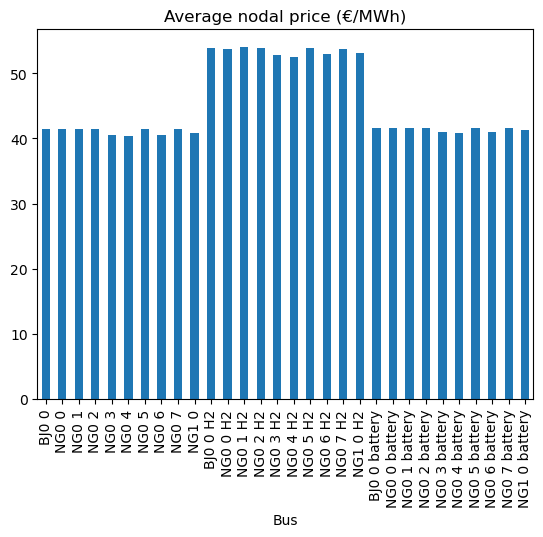

In [27]:
#Nodal prices (LMP)
n.buses_t.marginal_price.mean().sort_values(ascending=False)
n.buses_t.marginal_price.mean().plot(kind="bar", title="Average nodal price (€/MWh)")

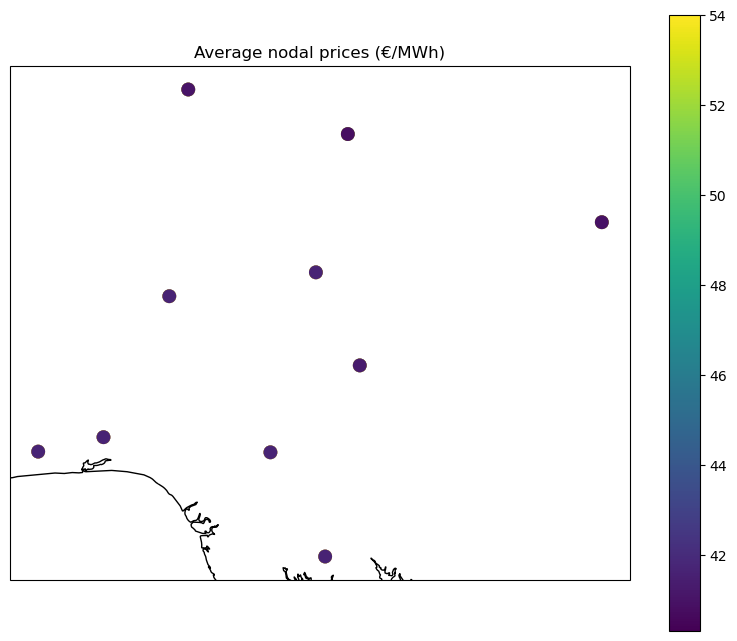

In [8]:
prices = n.buses_t.marginal_price.mean()
bus_geo["price"] = prices.values

fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_title("Average nodal prices (€/MWh)")
ax.coastlines()

bus_geo.plot(
    ax=ax,
    column="price",
    cmap="viridis",
    markersize=80,
    legend=True
)
plt.show()

LCOE totale sistema: 152.31 €/MWh



C:\Users\Lella\AppData\Local\Temp\ipykernel_15428\1485971439.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(n.generators.carrier, axis=1).sum() \
C:\Users\Lella\AppData\Local\Temp\ipykernel_15428\1485971439.py:18: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(n.generators.carrier, axis=1).sum().sum()


,CAPEX €/y,OPEX €/y,Energy MWh,LCOE €/MWh
BJ0 0 CCGT,NaN,0.0,NaN,NaN
BJ0 0 H2 load shedding,NaN,0.0,NaN,NaN
BJ0 0 battery load shedding,NaN,0.0,NaN,NaN
BJ0 0 load shedding,NaN,0.0,NaN,NaN
BJ0 0 offwind-ac,NaN,0.0,NaN,NaN
...,...,...,...,...
offwind-ac,0.000000e+00,0.0,0.00,NaN
offwind-dc,0.000000e+00,0.0,0.00,NaN
oil,8.017319e+05,0.0,0.00,4.924971e+12
onwind,0.000000e+00,0.0,0.00,6.626900e+02


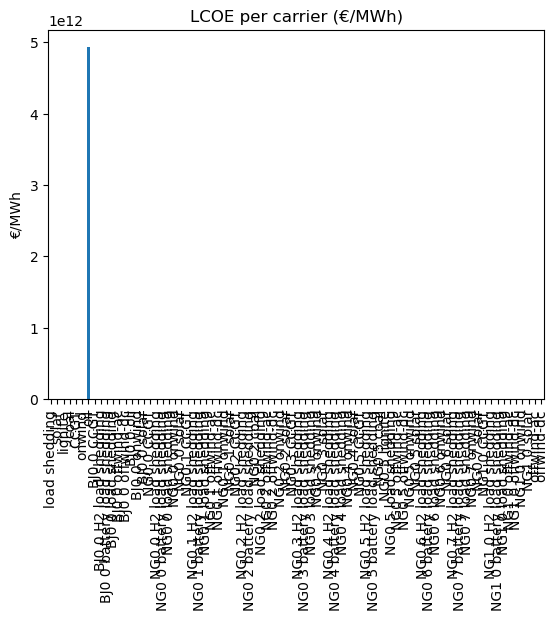

In [45]:
#LCOE
def compute_lcoe(n, plot=True):
    """
    Compute LCOE for a PyPSA-Earth network (compatible with 0.30+).
    Returns:
        lcoe_total (float)
        lcoe_carrier (pd.Series)
    """
    # CAPEX annualizzato per carrier
    capex = (n.generators.p_nom_opt * n.generators.capital_cost) \
            .groupby(n.generators.carrier).sum()
    # OPEX per carrier (marginal cost * energy generated)
    opex = (n.generators_t.p
            .groupby(n.generators.carrier, axis=1).sum() \
            * n.generators.marginal_cost).sum()
    # Energia prodotta per carrier
    energy = n.generators_t.p \
             .groupby(n.generators.carrier, axis=1).sum().sum()
    # LCOE per carrier
    lcoe_carrier = (capex + opex) / energy
    # LCOE totale del sistema
    lcoe_total = (capex.sum() + opex.sum()) / energy.sum()
    # Output tabella
    print(f"LCOE totale sistema: {lcoe_total:.2f} €/MWh\n")
    display(pd.DataFrame({
        "CAPEX €/y": capex.round(2),
        "OPEX €/y": opex.round(2),
        "Energy MWh": energy.round(2),
        "LCOE €/MWh": lcoe_carrier.round(2)
    }))
    if plot:
        lcoe_carrier.sort_values().plot(kind="bar", title="LCOE per carrier (€/MWh)")
        plt.ylabel("€/MWh")
        plt.show()
    return lcoe_total, lcoe_carrier
lcoe_total, lcoe_carrier = compute_lcoe(n)

In [59]:
#Emissions
co2_limit_Mt = n.global_constraints.loc["CO2Limit", "constant"] / 1e6
print(f"CO₂ limit: {co2_limit_Mt:.2f} MtCO₂")


emissions = (
    n.generators_t.p
    .multiply(n.generators.efficiency.reindex(n.generators_t.p.columns))
    .multiply(n.generators.carrier.map(n.carriers.co2_emissions))
).sum().sum()

print(f"Total emissions: {emissions/1e6:.2f} MtCO₂")

emissions_by_carrier = (
    n.generators_t.p
    .multiply(n.generators.carrier.map(n.carriers.co2_emissions))
    .sum()
    .groupby(n.generators.carrier).sum()
    .sort_values(ascending=False)
)

emissions_by_carrier.div(1e6).round(2)


CO₂ limit: 77.50 MtCO₂
Total emissions: 1.07 MtCO₂


carrier
CCGT             1.32
lignite          0.66
coal             0.24
oil              0.00
load shedding    0.00
offwind-ac       0.00
offwind-dc       0.00
onwind           0.00
solar            0.00
dtype: float64